In [1]:
from nanorsm import *

data_path = '//data//users//2023Q2//Murray_2023Q2//GAAFET_35_percent_10nm//'
sid_list = get_sid_list(['219710'],3)

elem_list = ['Ge_K','W_L','Ti_K']
num = np.size(sid_list)
i = 1
for elem in elem_list:
    file_list = []
    for sid in sid_list:
        tmp = ''.join([data_path, 'output_tiff_scan2D_','{}'.format(sid), '//detsum_',elem,'_norm.tiff'])
        
        file_list.append(tmp)
    im_stack = load_ims(file_list)
    
    #im_stack_test = interp_sub_pix(im_stack,trans_matrix)
    imp = np.sum(im_stack,0)
    imp.shape
    if i == 1:
        stack = imp
        sz = np.shape(imp)
        stack = np.reshape(stack, (1,sz[0],sz[1]))
    else:
        stack = np.concatenate((stack,imp[np.newaxis,:,:]),0)
    i = i+1
   
roi = [160,5,200,200]
mask = np.asarray(tifffile.imread('//data//users//2023Q2//Murray_2023Q2//nanodiffraction//mask.tif'))

diff_data = load_h5_data_db(sid_list,det='merlin2', roi=roi,mon='sclr1_ch4', mask = mask)
sz = diff_data.shape
diff_data = np.reshape(diff_data,[70,40,sz[2],sz[3]])
#diff_data[diff_data>10] = 0
sum_all = np.sum(np.sum(diff_data,-1),-1)
stack = np.concatenate((stack,sum_all[np.newaxis,:,:]))
elem_list.append('tot')
interactive_map(elem_list,stack,'diff',np.log10(diff_data+1e-6), marker_color = 'white')


Using matplotlib backend: Qt5Agg


Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Total scan points: 2800; raw image row: 502; raw image col: 495
Total scan points: 2800; data image row: 200; data image col: 200
Assume it is a rocking curve scan; number of angles = 2800


Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Total scan points: 40000; raw image row: 303; raw image col: 359
Total scan points: 40000; data image row: 303; data image col: 359
Assume it is a rocking curve scan; number of angles = 40000


TypeError: Invalid shape (1, 303, 359) for image data

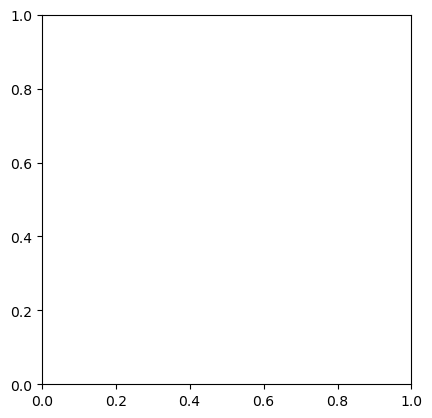

In [81]:
from nanorsm import *
sid = [338908]
det = 'merlin2'
desc = 'C_xBPM_on'
diff_data = load_h5_data_db(sid,det=det, mon='sclr1_ch2',threshold=[0,50000])
# tot = np.reshape(np.sum(np.sum(diff_data,-1),-1),[100,200])

# tifffile.imwrite(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_tot_norm_{desc}.tif",tot)
plt.imshow(diff_data[0])

In [91]:
%matplotlib qt
plt.imshow(diff_data[100,0,:,:])
plt.show()

In [41]:
# tot = np.reshape(np.sum(np.sum(diff_data,-1),-1),[100,200])
plt.imshow(tot)
plt.show()

In [55]:

diff_data = load_h5_data_db([339822],det='eiger_mobile_image', mon=None,threshold=[0,50000])
tot = np.reshape(np.sum(np.sum(diff_data,-1),-1),[100,200])

# tifffile.imwrite(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_tot_{desc}.tif",tot)

Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Total scan points: 20000; raw image row: 352; raw image col: 373
Total scan points: 20000; data image row: 352; data image col: 373
Assume it is a rocking curve scan; number of angles = 20000


Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Total scan points: 20000; raw image row: 352; raw image col: 373
Total scan points: 20000; data image row: 352; data image col: 373
Assume it is a rocking curve scan; number of angles = 20000


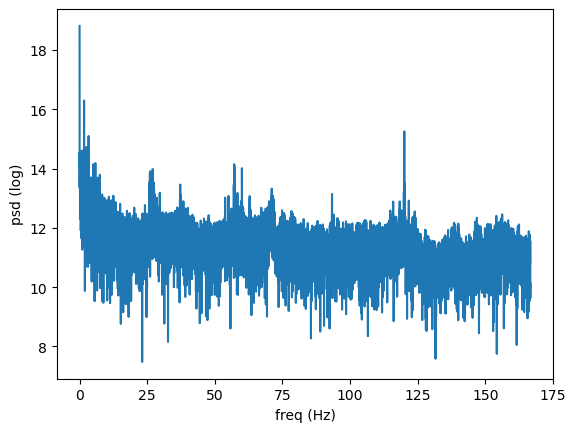

In [80]:
%matplotlib inline
sid =[339820]
desc='all_off'
diff_data = load_h5_data_db(sid,det='eiger_mobile_image', mon=None,threshold=[0,50000])
tot = np.reshape(np.sum(np.sum(diff_data,-1),-1),[100,200])


tot_fft = np.fft.fft(tot.ravel())
psd = np.abs(tot_fft)**2
sz = np.size(psd)
freq = np.linspace(0,sz//2,sz//2)/(0.003*sz)

plt.plot(freq,np.log10(psd[0:sz//2]))
plt.xlabel('freq (Hz)')
plt.ylabel('psd (log)')

plt.savefig(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_psd_{desc}.png")
np.savetxt(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_psd_{desc}.txt",
           np.hstack((freq.reshape((-1,1)),psd[0:sz//2].reshape((-1,1)))))

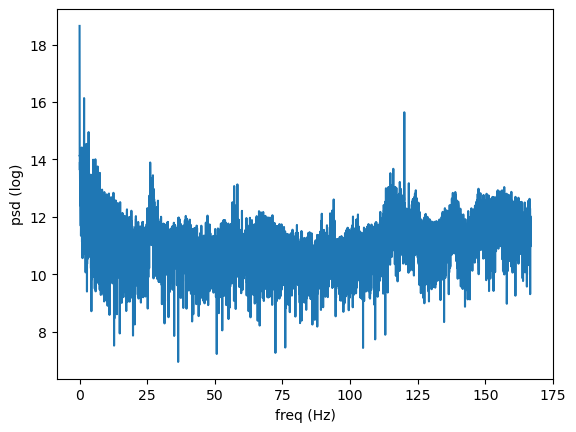

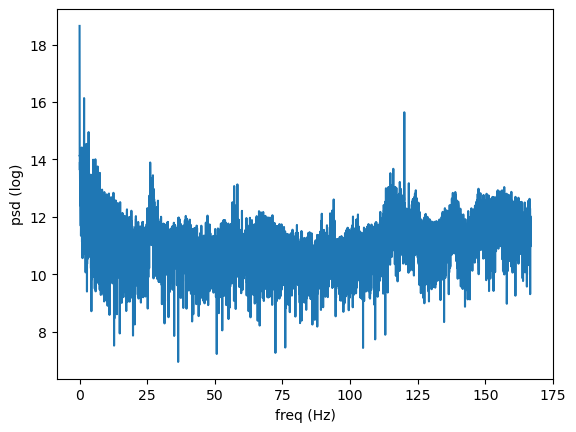

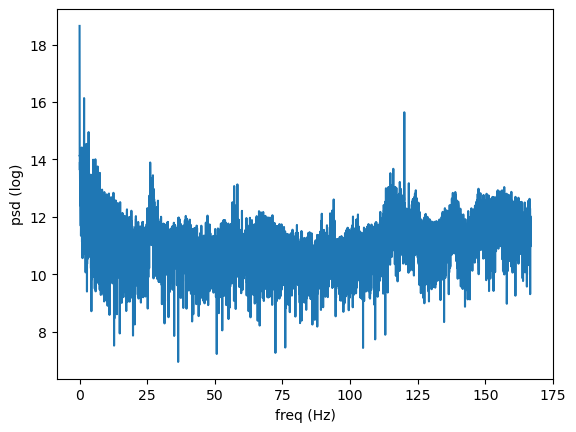

In [76]:
%matplotlib inline
plt.figure()
plt.plot(freq,np.log10(psd[0:sz//2]))
plt.xlabel('freq (Hz)')
plt.ylabel('psd (log)')

plt.savefig(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_psd_{desc}.png")
np.savetxt(f"/data/users/2025Q1/BPM_2025Q1/Apr_12_2025/{sid[0]}_psd_{desc}.txt",
           np.hstack((freq.reshape((-1,1)),psd[0:sz//2].reshape((-1,1)))))

In [2]:
file_name = ['//data//users//2023Q2//Murray_2023Q2//nanodiffraction//background_000001.h5']
data = load_h5_data(file_name,roi=None,mask=None)

Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Total scan points: 10; raw image row: 502; raw image col: 495
Total scan points: 10; data image row: 502; data image col: 495
Assume it is a rocking curve scan; number of angles = 10


In [17]:
tmp = np.squeeze(np.sum(data,0))
plt.figure()
plt.imshow(tmp*mask)

In [22]:
mask = np.ones(tmp.shape)
mask[tmp>10] = 0
mask[116,173] = 0
mask[221,112] = 0
mask[:,324] = 0
mask[145,247] = 0
mask[343,151] = 0
mask[445,312] = 0
mask[446,296] = 0
tifffile.imwrite('mask.tif',np.asarray(mask,dtype='float32'))

In [5]:
plt.figure()
plt.imshow(diff_data[10,0,:,:]*mask,clim=[0,1])